In [27]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from MDAnalysis.analysis import rms
from MDAnalysis.lib.distances import distance_array
import pandas as pd
from matplotlib.ticker import MultipleLocator

# Function to analyze a single trajectory
def analyze_trajectory(gro_file, xtc_file):
    u = mda.Universe(gro_file, xtc_file)
    ligand = u.select_atoms('resname AGLC')  # Adjust 'AGLC' to the actual ligand residue name
    protein = u.select_atoms('protein')
    selected_group = u.select_atoms('resid 173 406 461 557 487')  # Adjust 'resid 173 406 461 557 487' to your selected group

    if len(ligand) == 0:
        raise ValueError("Ligand selection is empty. Please check the residue name.")
    if len(selected_group) == 0:
        raise ValueError("Selected group is empty. Please check the residue IDs.")

    rmsd_values = []
    com_distances = []
    contact_counts = []

    R = rms.RMSD(u, ligand, select='resname AGLC')  # Adjust selection if needed
    R.run()

    for ts in u.trajectory:
        rmsd_values.append(R.rmsd[ts.frame, 2])  # RMSD values are stored in the 3rd column
        com_distance = np.linalg.norm(ligand.center_of_mass() - selected_group.center_of_mass())
        com_distances.append(com_distance)
        contact_matrix = distance_array(ligand.positions, protein.positions)
        contact_count = np.sum(contact_matrix < 5.0)
        contact_counts.append(contact_count)

    return rmsd_values, com_distances, contact_counts

# Load the simulation files for three trajectories
gro_files = [
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/md_center.gro',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/md_center.gro',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/md_center.gro'
]

xtc_files = [
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/500_center.xtc',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/500_center.xtc',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/500_center.xtc'
]

# Analyze each trajectory
results = [analyze_trajectory(gro_file, xtc_file) for gro_file, xtc_file in zip(gro_files, xtc_files)]

# Find the minimum length of the trajectories
min_length = min(len(res[0]) for res in results)

# Truncate all results to the minimum length
truncated_results = [(rmsd[:min_length], com[:min_length], contact[:min_length]) for rmsd, com, contact in results]

# Stack and average the results
stacked_rmsd_values = np.vstack([res[0] for res in truncated_results])
stacked_com_distances = np.vstack([res[1] for res in truncated_results])
stacked_contact_counts = np.vstack([res[2] for res in truncated_results])

avg_rmsd_values = np.mean(stacked_rmsd_values, axis=0)
avg_com_distances = np.mean(stacked_com_distances, axis=0)
avg_contact_counts = np.mean(stacked_contact_counts, axis=0)

# Create a dataframe for seaborn
data = pd.DataFrame({
    'COM Distance (Å)': avg_com_distances,
    'RMSD of Ligand (Å)': avg_rmsd_values,
    'Number of Contacts': avg_contact_counts
})

# Plot the results
plt.figure(figsize=(12, 8))
    #sns.set(style="white")


# Customize plot settings
x_range = (2, 11)
y_range = (0, 3.1)
#x_major_ticks = np.arange(5, 12, 1.5)  # Set appropriate x ticks
#y_major_ticks = np.arange(0, 3.0, 1.0)  # Set appropriate y ticks


# Create a JointGrid
g = sns.JointGrid(data=data, x="COM Distance (Å)", y="RMSD of Ligand (Å)", height=8)

# Add a kde plot with color mapping to the density
kde_plot = g.plot_joint(sns.kdeplot, cmap="YlOrBr", fill=True, cbar=False)
g.plot_marginals(sns.histplot, kde=True, color="goldenrod")

# Set axis limits
g.ax_joint.set_xlim(x_range)
g.ax_joint.set_ylim(y_range)

# Set major and minor ticks
#g.ax_joint = plt.gca()
g.ax_joint.xaxis.set_major_locator(MultipleLocator(2))
g.ax_joint.xaxis.set_minor_locator(MultipleLocator(1))
g.ax_joint.yaxis.set_major_locator(MultipleLocator(1))
g.ax_joint.yaxis.set_minor_locator(MultipleLocator(0.5))
g.ax_joint.tick_params(direction='out', length=5, width=1, labelsize=14)
#g.ax_joint_x.tick_params(direction='out', length=5, width=1, size=16)
# Apply tick parameters
#g.ax_joint.tick_params(direction='out', length=5, width=1, labelsize=14)

# Set labels
g.ax_joint.set_xlabel('COM Distance (Å)', fontsize=16, weight='bold')
g.ax_joint.set_ylabel('RMSD of Ligand (Å)', fontsize=16, weight='bold')
#g.ax_joint.grid(which='both')
# Add a separate colorbar for the KDE plot
cbar_ax = kde_plot.figure.add_axes([.99, .25, .02, .4])
vmin, vmax = 0, 1600  # Set the vmin and vmax for the colorbar
norm = plt.Normalize(vmin, vmax)
sm = plt.cm.ScalarMappable(cmap="YlOrBr", norm=norm)
sm.set_array([])
cbar = kde_plot.figure.colorbar(sm, cax=cbar_ax, label='Number of Contacts')
cbar.set_label('Number of Contacts', fontsize=16, weight='bold')
cbar.ax.tick_params(labelsize=14)

# Adjust the plot to make space for the color bar
plt.subplots_adjust(right=5)
plt.tight_layout()
# Save the plot with high resolution for publication
plt.savefig('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/500_RMSD_COM_Contacts.pdf', dpi=600, bbox_inches='tight')
plt.show()

/Users/chenyifang/opt/anaconda3/envs/gmxMMPBSA/lib/python3.9/site-packages/MDAnalysis/analysis/rms.py:718: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


KeyboardInterrupt: 

/Users/chenyifang/opt/anaconda3/envs/gmxMMPBSA/lib/python3.9/site-packages/MDAnalysis/analysis/rms.py:718: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)
/var/folders/6g/sb2r7d4n379gcm6jc9q5njlr0000gn/T/ipykernel_33789/567222419.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

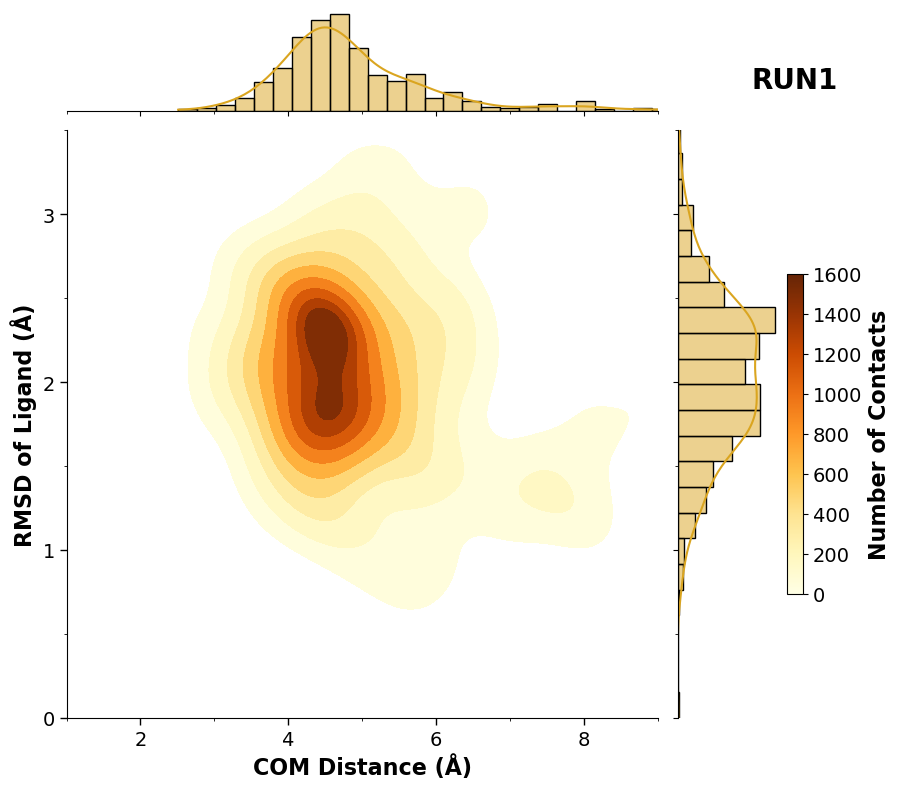

In [38]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from MDAnalysis.analysis import rms
from MDAnalysis.lib.distances import distance_array
import pandas as pd
from matplotlib.ticker import MultipleLocator

# Load the simulation files
u = mda.Universe('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/md_center.gro', '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/500_center.xtc')

# Define the ligand and protein selections
ligand = u.select_atoms('resname AGLC')  # Adjust 'AGLC' to the actual ligand residue name
protein = u.select_atoms('protein')
selected_group = u.select_atoms('resid 173 406 461 557 487')  # Adjust 'resid 173 406 461 557 487' to your selected group

# Check if selections are empty
if len(ligand) == 0:
    raise ValueError("Ligand selection is empty. Please check the residue name.")
if len(selected_group) == 0:
    raise ValueError("Selected group is empty. Please check the residue IDs.")

# Initialize arrays to store the results
rmsd_values = []
com_distances = []
contact_counts = []

# RMSD calculation object
R = rms.RMSD(u, ligand, select='resname AGLC')  # Adjust selection if needed
R.run()

# Iterate through each frame in the trajectory
for ts in u.trajectory:
    # Calculate the RMSD for the current frame
    rmsd_values.append(R.rmsd[ts.frame, 2])  # RMSD values are stored in the 3rd column

    # Calculate the center of mass distance between the ligand and the selected group
    com_distance = np.linalg.norm(ligand.center_of_mass() - selected_group.center_of_mass())
    com_distances.append(com_distance)

    # Calculate the number of contacts within 5 Å between the ligand and the protein
    contact_matrix = distance_array(ligand.positions, protein.positions)
    contact_count = np.sum(contact_matrix < 5.0)
    contact_counts.append(contact_count)

# Create a dataframe for seaborn
data = pd.DataFrame({
    'COM Distance (Å)': com_distances,
    'RMSD of Ligand (Å)': rmsd_values,
    'Number of Contacts': contact_counts
})

# Plot the results
plt.figure(figsize=(12, 8))
    #sns.set(style="white")


# Customize plot settings
x_range = (1, 9)
y_range = (0, 3.5)
#x_major_ticks = np.arange(5, 12, 1.5)  # Set appropriate x ticks
#y_major_ticks = np.arange(0, 3.0, 1.0)  # Set appropriate y ticks


# Create a JointGrid
g = sns.JointGrid(data=data, x="COM Distance (Å)", y="RMSD of Ligand (Å)", height=8)

# Add a kde plot with color mapping to the density
kde_plot = g.plot_joint(sns.kdeplot, cmap="YlOrBr", fill=True, cbar=False)
g.plot_marginals(sns.histplot, kde=True, color="goldenrod")

# Set axis limits
g.ax_joint.set_xlim(x_range)
g.ax_joint.set_ylim(y_range)

# Set major and minor ticks
#g.ax_joint = plt.gca()
g.ax_joint.xaxis.set_major_locator(MultipleLocator(2))
g.ax_joint.xaxis.set_minor_locator(MultipleLocator(1))
g.ax_joint.yaxis.set_major_locator(MultipleLocator(1))
g.ax_joint.yaxis.set_minor_locator(MultipleLocator(0.5))
g.ax_joint.tick_params(direction='out', length=5, width=1, labelsize=14)
#g.ax_joint_x.tick_params(direction='out', length=5, width=1, size=16)
# Apply tick parameters
#g.ax_joint.tick_params(direction='out', length=5, width=1, labelsize=14)

# Set labels
g.ax_joint.set_xlabel('COM Distance (Å)', fontsize=16, weight='bold')
g.ax_joint.set_ylabel('RMSD of Ligand (Å)', fontsize=16, weight='bold')
#g.ax_joint.grid(which='both')
# Add a separate colorbar for the KDE plot
cbar_ax = kde_plot.figure.add_axes([.99, .25, .02, .4])
vmin, vmax = 0, 1600  # Set the vmin and vmax for the colorbar
norm = plt.Normalize(vmin, vmax)
sm = plt.cm.ScalarMappable(cmap="YlOrBr", norm=norm)
sm.set_array([])
cbar = kde_plot.figure.colorbar(sm, cax=cbar_ax, label='Number of Contacts')
cbar.set_label('Number of Contacts', fontsize=16, weight='bold')
cbar.ax.tick_params(labelsize=14)

# Adjust the plot to make space for the color bar
plt.subplots_adjust(right=5)
plt.title('RUN1', fontsize=20, weight='bold', pad=150, verticalalignment='top')
plt.tight_layout()
# Save the plot with high resolution for publication
plt.savefig('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/500_RMSD_COM_Contacts_R1.pdf', dpi=600, bbox_inches='tight')
plt.show()

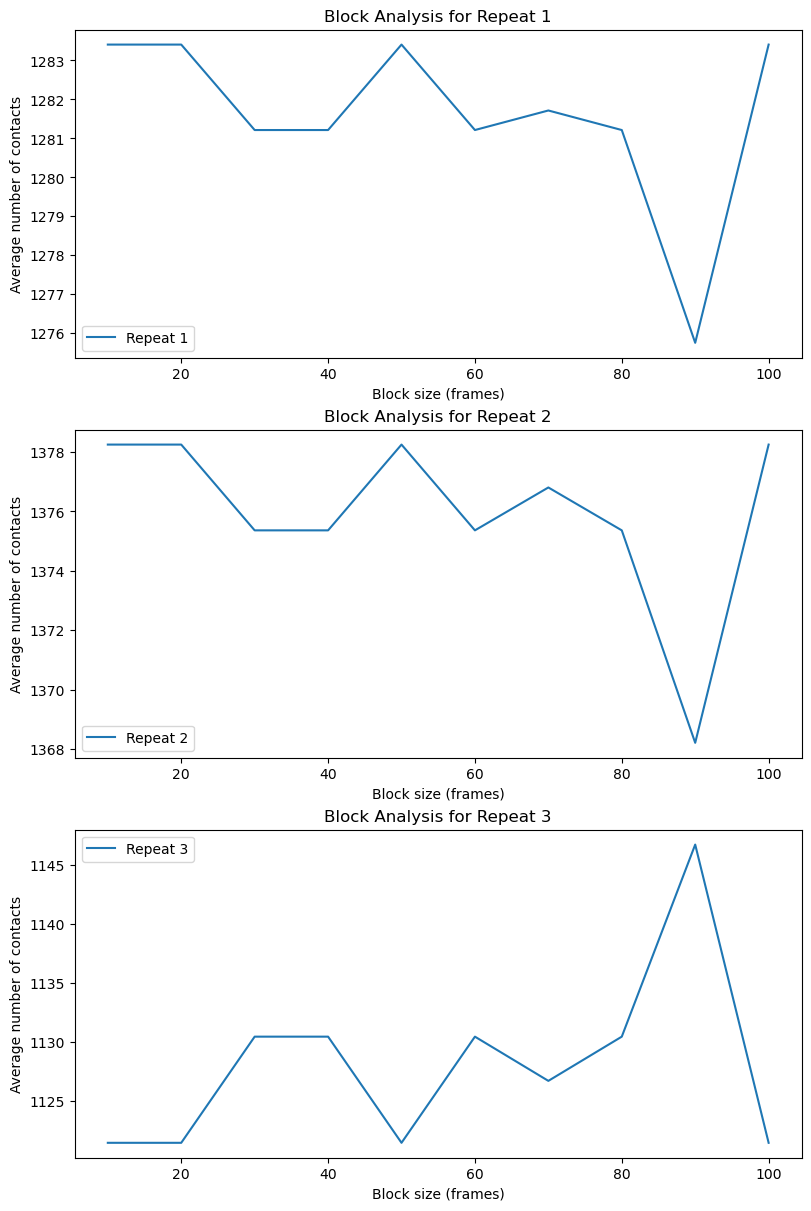

In [40]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate number of contacts within a cutoff distance
def count_contacts(universe, ligand_sel, protein_sel, cutoff=5.0):
    ligand_atoms = universe.select_atoms(ligand_sel)
    protein_atoms = universe.select_atoms(protein_sel)
    
    contacts_count = []
    for ts in universe.trajectory:
        # Calculate pairwise distances
        distances = np.linalg.norm(protein_atoms.positions[:, np.newaxis, :] - ligand_atoms.positions[np.newaxis, :, :], axis=-1)
        # Check if any distance is within the cutoff
        contacts = np.sum(distances < cutoff)
        contacts_count.append(contacts)
    
    return np.array(contacts_count)

# Function to perform block averaging for convergence
def block_analysis(contacts, block_sizes):
    block_means = []
    for block_size in block_sizes:
        num_blocks = len(contacts) // block_size
        blocks = [contacts[i*block_size:(i+1)*block_size] for i in range(num_blocks)]
        block_avg = np.mean([np.mean(block) for block in blocks])
        block_means.append(block_avg)
    return block_means

# Parameters (Modify these according to your file names and selection strings)
gro_files = ['/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/md_center.gro', '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/md_center.gro', '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/md_center.gro']  # Replace with your GRO files
xtc_files = ['/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/500_center.xtc', '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/500_center.xtc', '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/500_center.xtc']  # Replace with your XTC files
ligand_selection = 'resname AGLC'  # Modify as needed
protein_selection = 'protein'
cutoff_distance = 5.0  # Distance cutoff in Å
block_sizes = np.arange(10, 101, 10)  # Define block sizes for block analysis

# Main script
fig, axs = plt.subplots(3, 1, layout='constrained', figsize=(8, 12))  # Create 3 subplots

for i, (gro_file, xtc_file) in enumerate(zip(gro_files, xtc_files)):
    u = mda.Universe(gro_file, xtc_file)
    contacts = count_contacts(u, ligand_selection, protein_selection, cutoff=cutoff_distance)
    block_means = block_analysis(contacts, block_sizes)
    
    # Plotting for each repeat
    axs[i].plot(block_sizes, block_means, label=f'Repeat {i+1}')
    axs[i].set_xlabel('Block size (frames)')
    axs[i].set_ylabel('Average number of contacts')
    axs[i].set_title(f'Block Analysis for Repeat {i+1}')
    axs[i].legend()

# Display the plots
plt.show()


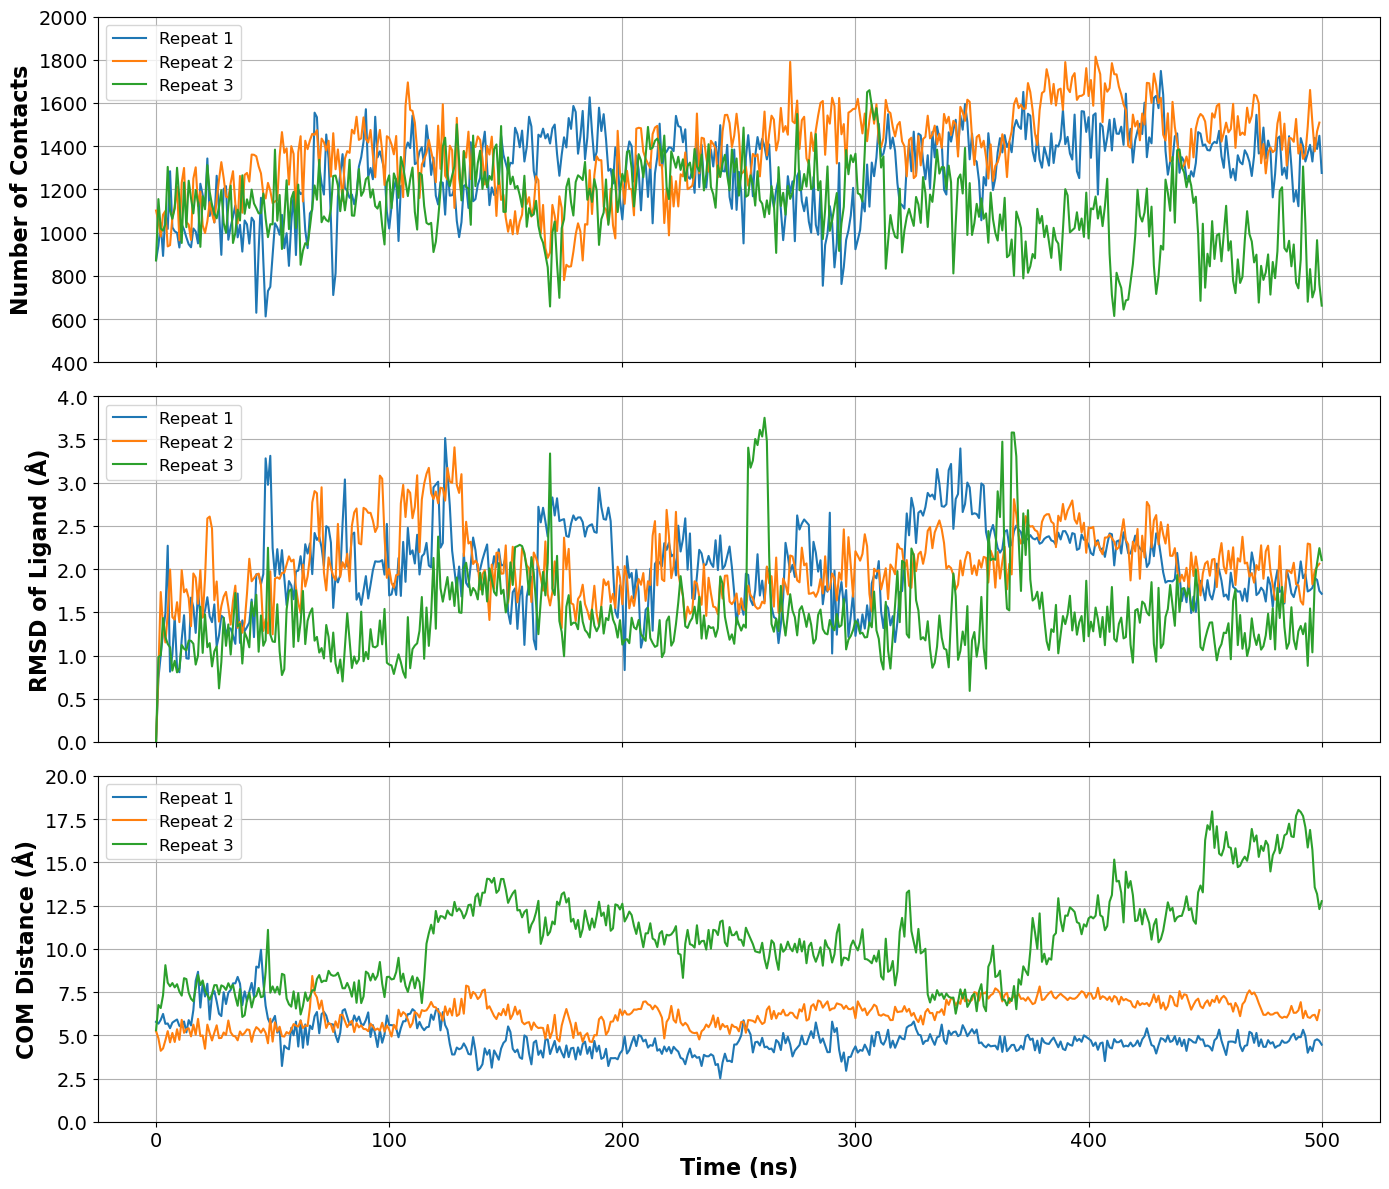

In [45]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis import rms
from MDAnalysis.lib.distances import distance_array

# Function to analyze a single trajectory
def analyze_trajectory(gro_file, xtc_file):
    u = mda.Universe(gro_file, xtc_file)
    ligand = u.select_atoms('resname AGLC')  # Adjust 'AGLC' to the actual ligand residue name
    protein = u.select_atoms('protein')
    selected_group = u.select_atoms('resid 173 406 461 557 487')  # Adjust this to your selected group

    if len(ligand) == 0:
        raise ValueError("Ligand selection is empty. Please check the residue name.")
    if len(selected_group) == 0:
        raise ValueError("Selected group is empty. Please check the residue IDs.")

    rmsd_values = []
    com_distances = []
    contact_counts = []

    R = rms.RMSD(u, ligand, select='resname AGLC')  # Adjust selection if needed
    R.run()

    for ts in u.trajectory:
        rmsd_values.append(R.rmsd[ts.frame, 2])  # RMSD values are stored in the 3rd column
        com_distance = np.linalg.norm(ligand.center_of_mass() - selected_group.center_of_mass())
        com_distances.append(com_distance)
        contact_matrix = distance_array(ligand.positions, protein.positions)
        contact_count = np.sum(contact_matrix < 5.0)
        contact_counts.append(contact_count)

    return rmsd_values, com_distances, contact_counts

# Load the simulation files for three trajectories
gro_files = [
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/md_center.gro',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/md_center.gro',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/md_center.gro'
]

xtc_files = [
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/500_center.xtc',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/500_center.xtc',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/500_center.xtc'
]

# Analyze each trajectory
results = [analyze_trajectory(gro_file, xtc_file) for gro_file, xtc_file in zip(gro_files, xtc_files)]

# Plot the time series for each variable
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 12), sharex=True)
variables = ['Number of Contacts', 'RMSD of Ligand (Å)', 'COM Distance (Å)']
colors = ['tab:blue', 'tab:orange', 'tab:green']  # Colors for each repeat

# Define y-limits for each subplot (variable)
ylims = [(400, 2000),  # For Number of Contacts
         (0, 4),     # For RMSD of Ligand (Å)
         (0, 20)]    # For COM Distance (Å)

# Loop through each subplot and plot the corresponding data
for i, ax in enumerate(axes):
    for j, result in enumerate(results):
        if i == 0:
            ax.plot(result[2], label=f'Repeat {j+1}', color=colors[j])
        elif i == 1:
            ax.plot(result[0], label=f'Repeat {j+1}', color=colors[j])
        elif i == 2:
            ax.plot(result[1], label=f'Repeat {j+1}', color=colors[j])
    
    ax.set_ylabel(variables[i], fontsize=16, weight='bold')
    ax.set_ylim(ylims[i])
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True)
    ax.tick_params(axis='both', which='major', labelsize=14)

# Set common x-label for time
axes[-1].set_xlabel('Time (ns)', fontsize=16, weight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/TimeSeries_RMSD_COM_Contacts.pdf', dpi=600, bbox_inches='tight')
plt.show()

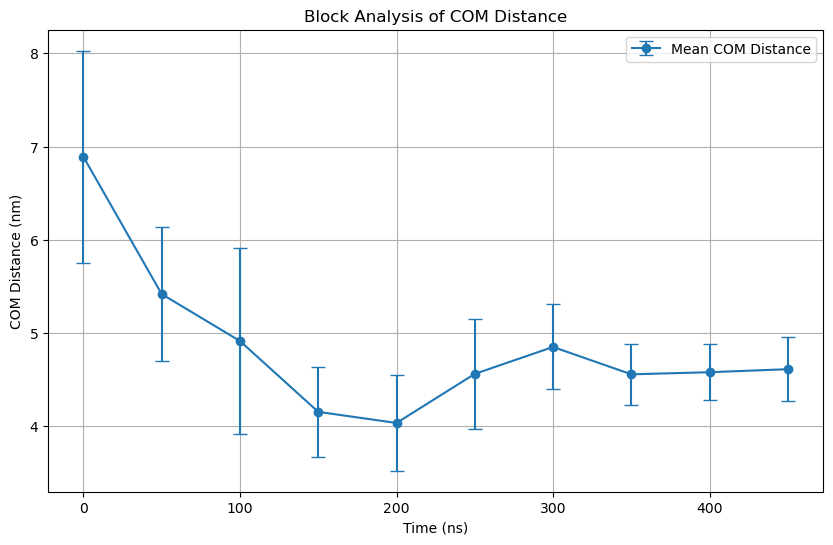

In [48]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

# Load the trajectory and topology files
u = mda.Universe('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/md_center.gro', '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/500_center.xtc')

# Define the two groups of atoms (you need to specify the selection)
group1 = u.select_atoms('resname AGLC')  # Modify this selection based on your groups
group2 = u.select_atoms('resid 173 406 461 557 487')  # Modify this selection based on your groups

# Function to calculate the COM distance between two groups
def compute_com_distance(group1, group2):
    com1 = group1.center_of_mass()
    com2 = group2.center_of_mass()
    return np.linalg.norm(com1 - com2)

# Block analysis function
def block_analysis(data, block_size):
    num_blocks = len(data) // block_size
    block_means = []
    block_stds = []
    
    for i in range(num_blocks):
        block = data[i * block_size:(i + 1) * block_size]
        block_mean = np.mean(block)
        block_std = np.std(block)
        block_means.append(block_mean)
        block_stds.append(block_std)
    
    return np.array(block_means), np.array(block_stds)

# Calculate COM distances for the entire trajectory
com_distances = []
for ts in u.trajectory:
    com_distances.append(compute_com_distance(group1, group2))

com_distances = np.array(com_distances)

# Define the block size (for example, 25 frames)
block_size = 50

# Perform block analysis
block_means, block_stds = block_analysis(com_distances, block_size)

# Plot the results
time = np.arange(0, len(block_means) * block_size, block_size)  # Time in frames (or ns)

plt.figure(figsize=(10, 6))
plt.errorbar(time, block_means, yerr=block_stds, fmt='o-', capsize=5, label='Mean COM Distance')
plt.xlabel('Time (ns)')
plt.ylabel('COM Distance (nm)')
plt.title('Block Analysis of COM Distance')
plt.grid(True)
plt.legend()
plt.show()


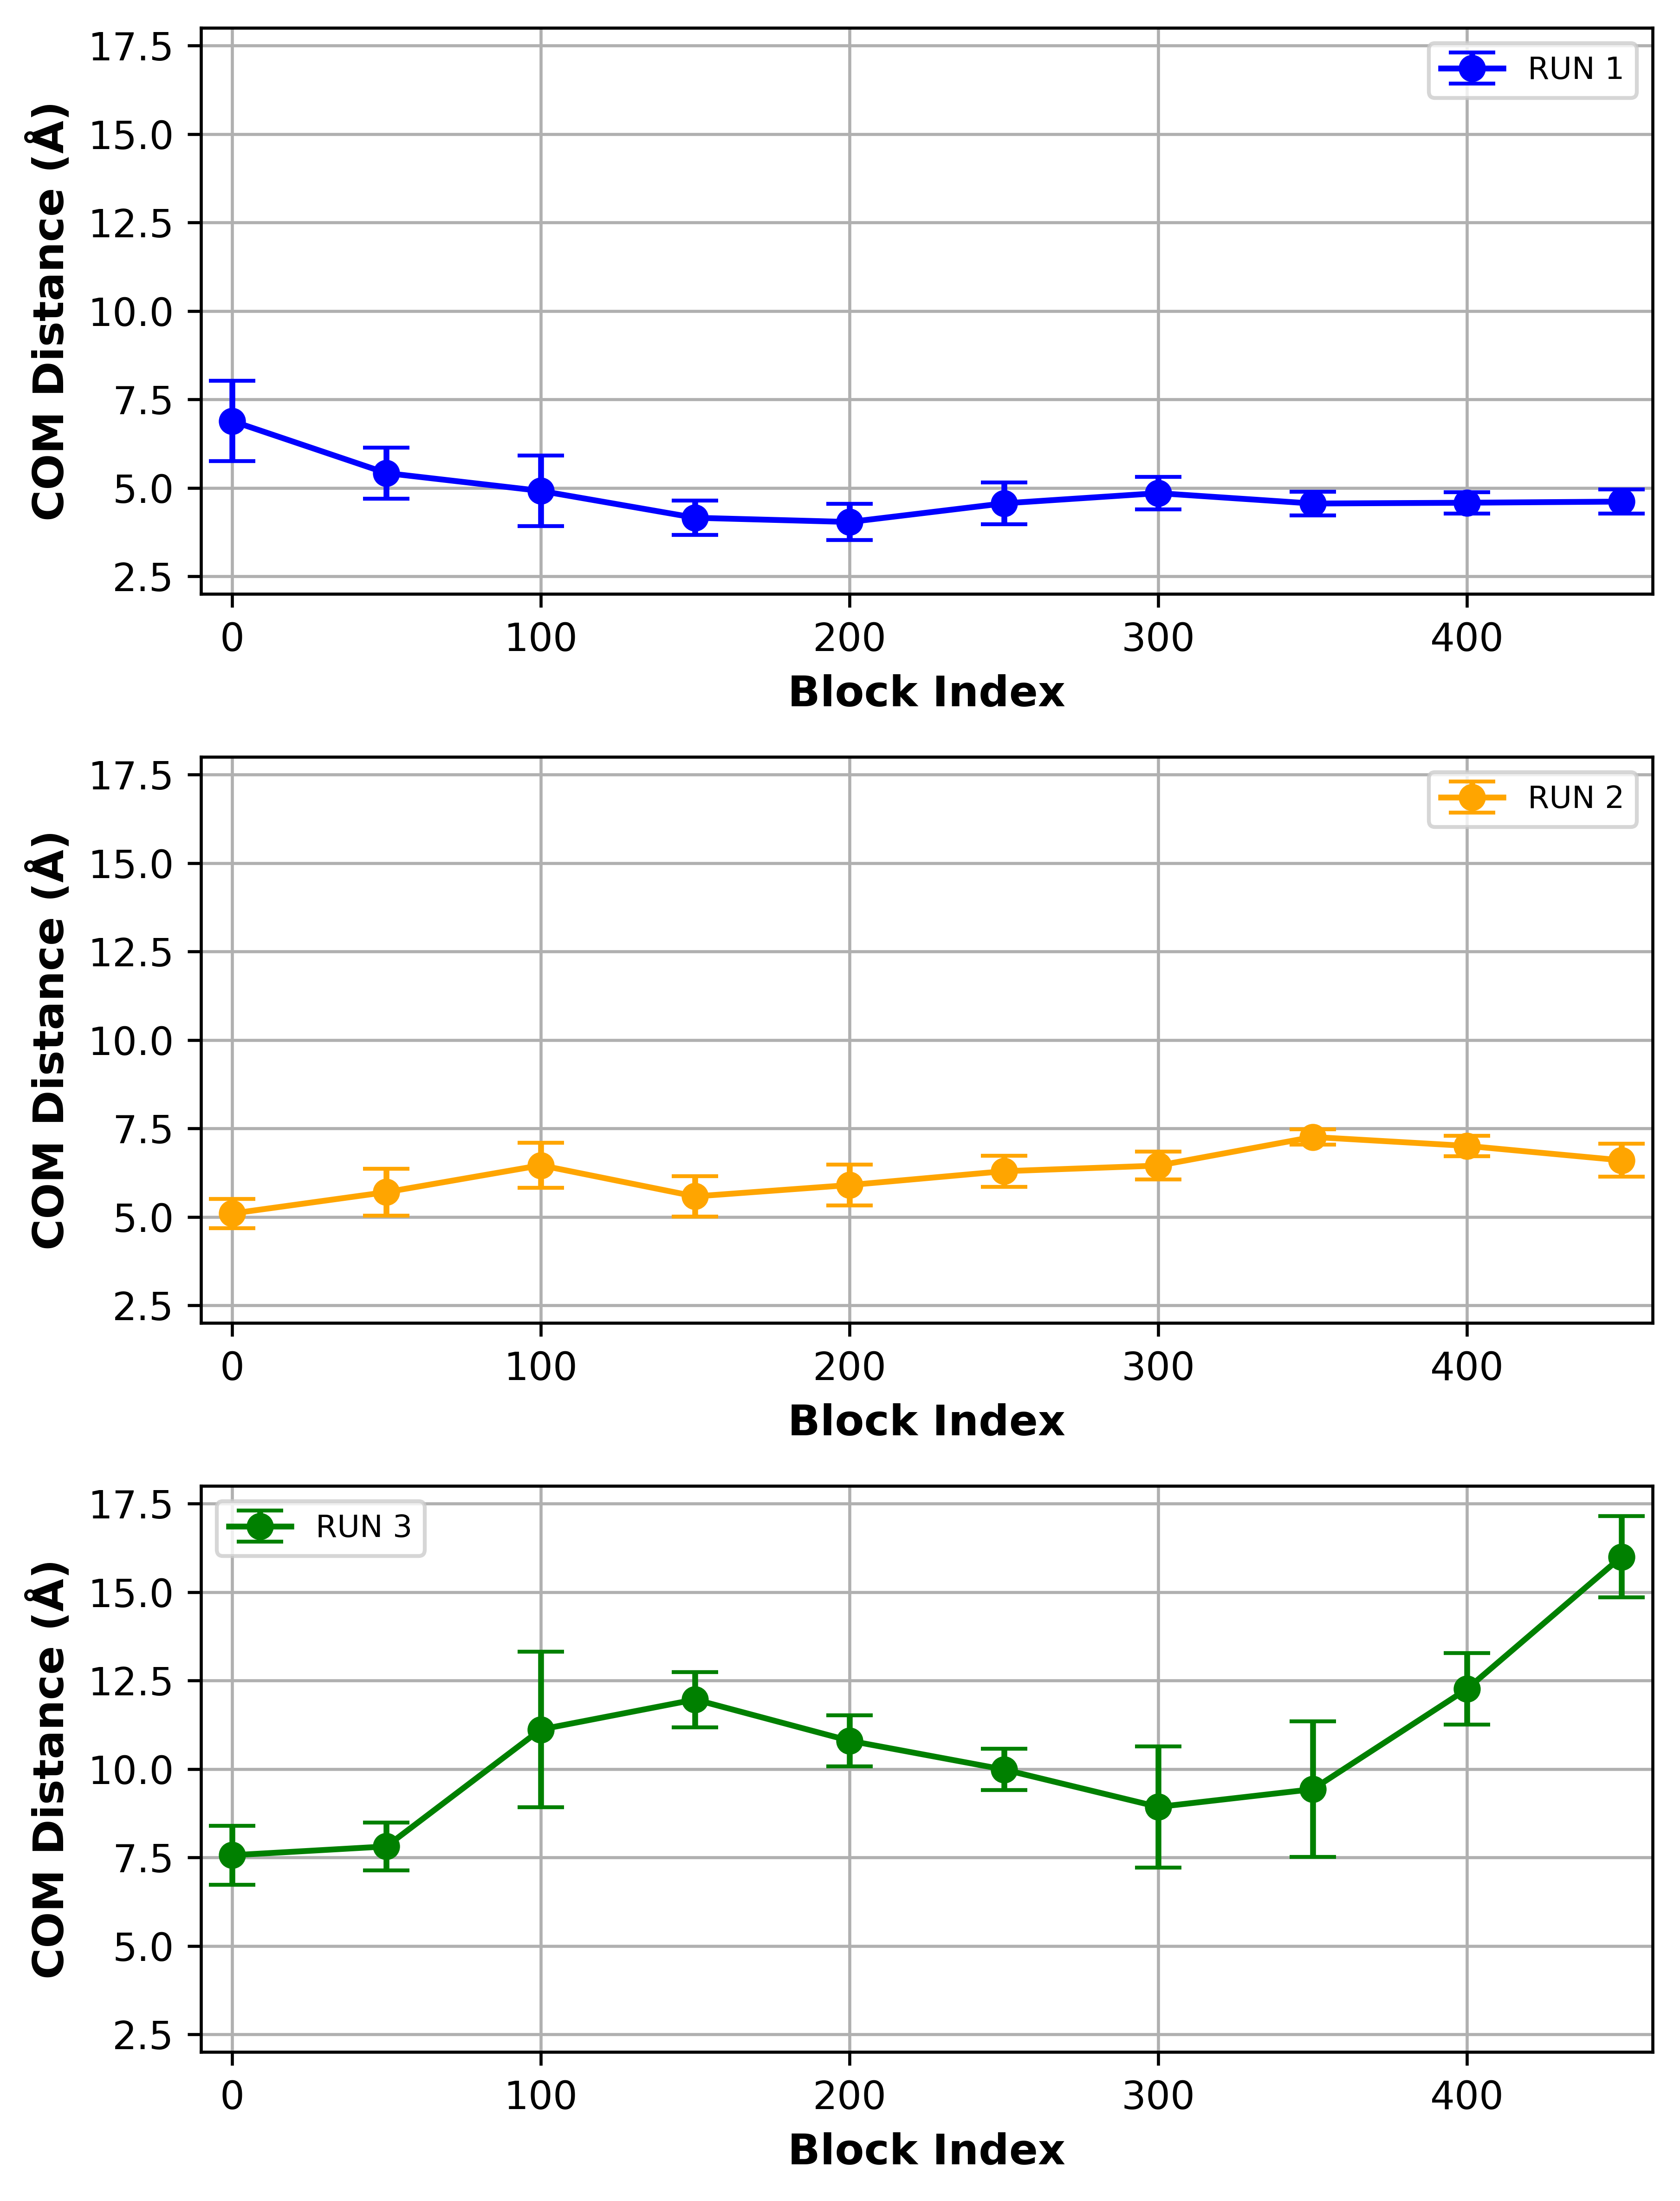

In [62]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate the COM distance between two groups
def compute_com_distance(u, group1_selection, group2_selection):
    group1 = u.select_atoms(group1_selection)
    group2 = u.select_atoms(group2_selection)
    com1 = group1.center_of_mass()
    com2 = group2.center_of_mass()
    return np.linalg.norm(com1 - com2)

# Block analysis function
def block_analysis(data, block_size):
    num_blocks = len(data) // block_size
    block_means = []
    block_stds = []
    
    for i in range(num_blocks):
        block = data[i * block_size:(i + 1) * block_size]
        block_mean = np.mean(block)
        block_std = np.std(block)
        block_means.append(block_mean)
        block_stds.append(block_std)
    
    return np.array(block_means), np.array(block_stds)

# Define replica files and selections
replica_files = [
    ('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/md_center.gro', '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/500_center.xtc', 'resname AGLC', 'resid 173 406 461 557 487'),
    ('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/md_center.gro', '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/500_center.xtc', 'resname AGLC', 'resid 173 406 461 557 487'),
    ('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/md_center.gro', '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/500_center.xtc', 'resname AGLC', 'resid 173 406 461 557 487')
]

#Define colors for each replica
colors = ['blue', 'orange', 'green']

# Create a figure with subplots
fig, axs = plt.subplots(3, 1, figsize=(6, 8), dpi=600)
fig.subplots_adjust(hspace=0.3)  # Adjust space between subplots

# Define block size
block_size = 50

# Set x and y limits (modify these as needed)
x_limits = (-10, 460)  # Set the x-axis limits in ns (or frames)
y_limits = (2, 18)  # Set the y-axis limits for COM distance

# Loop through each replica
for i, (gro_file, xtc_file, group1_selection, group2_selection) in enumerate(replica_files):
    u = mda.Universe(gro_file, xtc_file)

    # Calculate COM distances for the entire trajectory
    com_distances = []
    for ts in u.trajectory:
        distance = compute_com_distance(u, group1_selection, group2_selection)
        com_distances.append(distance)

    com_distances = np.array(com_distances)

    # Perform block analysis
    block_means, block_stds = block_analysis(com_distances, block_size)
    time = np.arange(0, len(block_means) * block_size, block_size)  # Time in frames (or ns)

    # Plot the results for each replica
    axs[i].errorbar(time, block_means, yerr=block_stds, fmt='o-', color=colors[i], capsize=6, label=f'RUN {i + 1}')
    axs[i].set_xlabel('Block Index', fontsize=11, weight='bold')
    axs[i].set_ylabel('COM Distance (Å)', fontsize=11, weight='bold')
    #axs[i].set_title(f'RUN {i + 1}', fontsize=12, weight='bold')
    axs[i].set_xlim(x_limits)  # Set x limits
    axs[i].set_ylim(y_limits)  # Set y limits
    axs[i].grid(True)
    axs[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/Block_analysis.pdf', dpi=600, bbox_inches='tight')
plt.show()

